In [1]:
using Pkg
Pkg.activate("/home/gridsan/aligho/Github_Projects/JJDFTX.jl/")
ENV["JULIA_REVISE_POLL"]="1";
using Revise

In [2]:
using PyPlot, PyCall, Peaks, Statistics, JJDFTX, LinearAlgebra, StatsBase;

┌ Info: Precompiling JJDFTX [0d21db8c-e7cb-497b-98f4-4306b49e2569]
└ @ Base loading.jl:1317


Your version of python is not linked to helper_scripts.py
Your version of python is not linked to the Atomic Simulation Environment


In [3]:
ndimage = pyimport("scipy.ndimage") 

PyObject <module 'scipy.ndimage' from '/home/gridsan/aligho/.local/lib/python3.8/site-packages/scipy/ndimage/__init__.py'>

In [244]:
# Make sure output files are copacetic

In [4]:
v1, v2, v3 = loadlattice("Moire-1-1.out");

In [5]:
loadcellarea("Moire-1-1.out")/13/(1.44^2*3*sqrt(3)/2)

1.0060468944791943

In [6]:
reciprocal_vectors(loadlattice("Moire-1-1.out"))

([0.5795981074290497, -0.5577164196143838, -0.0], [-0.19319873995207945, -0.780803931246543, 0.0], [-0.0, 0.0, 0.2968376038253546])

In [7]:
g1, g2, g3 = loadreciprocallattice("Moire-1-1.out")

3-element Vector{Vector{Float64}}:
 [0.5795981306821725, -0.5577169831644232, -0.0]
 [-0.19319811707613896, -0.7808030205394415, 0.0]
 [-0.0, 0.0, 0.2968382979607957]

In [8]:
[[round(sum(a.*b), digits=3) for a in loadlattice("Moire-1-1.out")] for b in loadreciprocallattice("Moire-1-1.out")]

3-element Vector{Vector{Float64}}:
 [6.283, 0.0, 0.0]
 [0.0, 6.283, 0.0]
 [0.0, 0.0, 6.283]

In [9]:
unit_cell_array=zeros(600, 600);
for i in 1:600
    for j in 1:600
        unit_cell_array[i, j] = in_wigner_seitz([v1, v2, v3], [(i-300)/48, (j-300)/48, 0])
    end
end

In [45]:
x1, y1 = v1[1:2]*24
x2, y2 = v2[1:2]*24
x3, y3 = (-v1)[1:2]*24
x4, y4 = (v2+v1)[1:2]*24
x5, y5 = -(v2+v1)[1:2]*24
x6, y6 = (-v2)[1:2]*24


xg, yg = g1[1:2]/sqrt(dot(g1[1:2], g1[1:2]))*sqrt(dot(v1, v1))*24/sqrt(3);
xg2, yg2 = g2[1:2]/sqrt(dot(g1[1:2], g1[1:2]))*sqrt(dot(v1, v1))*24/sqrt(3);
xg3, yg3 = (g1-g2)[1:2]/sqrt(dot(g1[1:2], g1[1:2]))*sqrt(dot(v1, v1))*24/sqrt(3);

In [46]:
dot(g1-g2, g1-g2)

0.6469814206210135

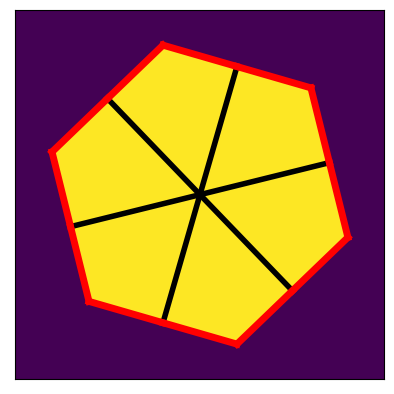

(Any[], Any[])

In [56]:
imshow(transpose(unit_cell_array))
plot([300, x1+300], [300, y1+300], linewidth=4, linestyle="solid", label="1", color="black")
plot([300, x2+300], [300, y2+300], linewidth=4, linestyle="solid", label="2", color="black")
plot([300, x3+300], [300, y3+300], linewidth=4, linestyle="solid", label="3", color="black")
plot([300, x4+300], [300, y4+300], linewidth=4, linestyle="solid", label="4", color="black")
plot([300, x5+300], [300, y5+300], linewidth=4, linestyle="solid", label="5", color="black")
plot([300, x6+300], [300, y6+300], linewidth=4, linestyle="solid", label="6", color="black")

plot([x6+300, xg+x6+300], [y6+300, yg+y6+300], linewidth=5, linestyle="solid", color="red")
plot([x6+300, -xg+x6+300], [y6+300, -yg+y6+300], linewidth=5, linestyle="solid", color="red")

plot([x2+300, xg+x2+300], [y2+300, yg+y2+300], linewidth=5, linestyle="solid", color="red")
plot([x2+300, -xg+x2+300], [y2+300, -yg+y2+300], linewidth=5, linestyle="solid", color="red")


plot([x1+300, xg2+x1+300], [y1+300, yg2+y1+300], linewidth=5, linestyle="solid", color="red")
plot([x1+300, -xg2+x1+300], [y1+300, -yg2+y1+300], linewidth=5, linestyle="solid", color="red")
plot([x3+300, xg2+x3+300], [y3+300, yg2+y3+300], linewidth=5, linestyle="solid", color="red")
plot([x3+300, -xg2+x3+300], [y3+300, -yg2+y3+300], linewidth=5, linestyle="solid", color="red")


plot([x4+300, xg3+x4+300], [y4+300, yg3+y4+300], linewidth=5, linestyle="solid", color="red")
plot([x4+300, -xg3+x4+300], [y4+300, -yg3+y4+300], linewidth=5, linestyle="solid", color="red")
plot([x5+300, xg3+x5+300], [y5+300, yg3+y5+300], linewidth=5, linestyle="solid", color="red")
plot([x5+300, -xg3+x5+300], [y5+300, -yg3+y5+300], linewidth=5, linestyle="solid", color="red")

xticks(Float64[])
yticks(Float64[])
#xlim(40, 550)
#ylim(40, 550)
#legend()
#xlim(100, 240)
#ylim(100, 240)

In [58]:
normalize_kvector((v1, v2, v3), g3)

3-element Vector{Float64}:
 0.0
 0.0
 1.0000023384349965

In [3]:
Energies = zeros(10, 10)
for i in 0:9
    for j in 0:9
        try
        Energies[i+1, j+1] = list_energy("Moire-$i-$j.out")
        catch e
            println("File Not Found")
        end
    end
end

In [26]:
Energies_single = zeros(10, 10)
for i in 1:10
    for j in 1:10
        try
        Energies_single[i, j] = list_energy("../single_atom_stability/Moire-$i-$j.out")
        catch e
            println("File Not Found")
        end
    end
end

In [42]:
argmin(Energies_single[1:2, 1:2] + Energies[1:2, 1:2])

CartesianIndex(1, 1)

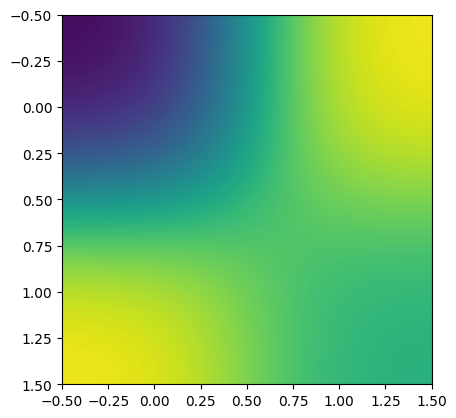

PyObject <matplotlib.image.AxesImage object at 0x7f8df9ba27c0>

In [155]:
imshow(Energies_single[1:2, 1:2] + Energies[1:2, 1:2], interpolation="Gaussian")

In [156]:
v1, v2, v3 = loadlattice("Moire-1-1.out");

In [6]:
det(hcat(v1, v2, v3))/sqrt(sum(v3.*v3))/13/1.44/1.44/3*2/sqrt(3)

-1.00604378745101

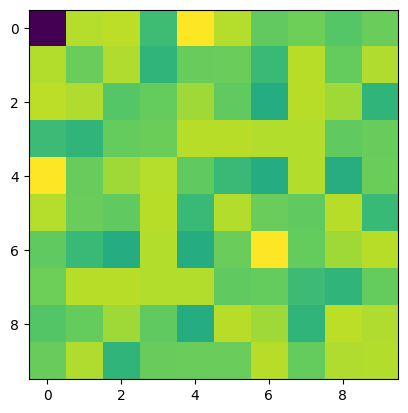

PyObject <matplotlib.image.AxesImage object at 0x7f8dfde2fdf0>

In [9]:
imshow(log.( Energies .- minimum(Energies) .+ 0.001))

In [8]:
Energies[10, 6] = Energies[10, 5]

-10242.25632315161

In [10]:
lattice_to_cartesian = hcat(v1[1:2], v2[1:2])/sqrt(sum(v1.*v1))*225/10

2×2 Matrix{Float64}:
 21.8413   -15.6009
 -5.40432  -16.213

In [11]:
cartesian_to_lattice = inv(lattice_to_cartesian)

2×2 Matrix{Float64}:
  0.03698    -0.0355839
 -0.0123266  -0.0498176

In [12]:
zEnergies=zscore(Energies)

10×10 Matrix{Float64}:
 -3.00785    0.92138    1.12187   …  -0.272245  -0.647685  -0.348773
  0.911753  -0.353384   0.846985      0.985699  -0.393816   0.849718
  1.11236    0.848238  -0.655098      1.01548    0.575512  -1.22797
 -1.01047   -1.23124   -0.40534       0.903602  -0.47511   -0.383781
  2.66347   -0.388505   0.56454       0.900034  -1.4296    -0.319672
  0.9202    -0.326455  -0.483782  …  -0.487194   1.00939   -1.07422
 -0.4694    -1.07563   -1.43409      -0.399692   0.564038   0.98143
 -0.282093   0.981368   1.01435      -1.01859   -1.23945   -0.399945
 -0.65752   -0.397792   0.573853     -1.23752    1.11031    0.84486
 -0.358626   0.850703  -1.22627      -0.403762   0.846083   0.914726

In [147]:
zEnergies_stability=zscore(Energies_single[1:2, 1:2]+Energies[1:2, 1:2])

2×2 Matrix{Float64}:
 -1.3915    0.730868
  0.72486  -0.0642233

In [13]:
function returnE(x::Vector{<:Real})
    i, j = Int.(round.(cartesian_to_lattice*x)) 
    i, j = rem.([i, j], 10)
    i < 0 && (i = i+10)
    j < 0 && (j = j+10)
   #(i==0 && j==0) &&  println(i, " ", j)

    return (zEnergies[i+1, j+1])
end

returnE (generic function with 1 method)

In [142]:
function returnE_stability(x::Vector{<:Real})
    i, j = Int.(round.(cartesian_to_lattice*x)) 
    i, j = rem.([i, j], 10)
    i < 0 && (i = i+10)
    j < 0 && (j = j+10)
   #(i==0 && j==0) &&  println(i, " ", j)

    #=(i != 9  && j != 9) && return (zEnergies_stability[i+1, j+1])
    (i == 9  && j != 9) && return (zEnergies_stability[9, j+1])
    (i != 9  && j == 9) && return (zEnergies_stability[i+1, 9])
    (i == 9  && j == 9) && return (zEnergies_stability[9, 9])
=#
    if (i < 2) && (j < 2)
        return zEnergies_stability[i+1, j+1]
    else
        return 0
    end
end

returnE_stability (generic function with 1 method)

In [117]:
N=800
EnergyArray = zeros(N, N)
for i in 1:N
    for j in 1:N
        r=[i, j] -[35, 0]
        EnergyArray[i, j] = returnE(r)
        #EnergyArray[i, j]  = log(returnE([i, j]) - minimum(Energies) .+ 0.1)
    end
end

In [143]:
N=800
EnergyArrayStability = zeros(N, N)
for i in 1:N
    for j in 1:N
        r=[i, j] -[35, 0]
        EnergyArrayStability[i, j] = returnE_stability(r)
        #EnergyArray[i, j]  = log(returnE([i, j]) - minimum(Energies) .+ 0.1)
    end
end

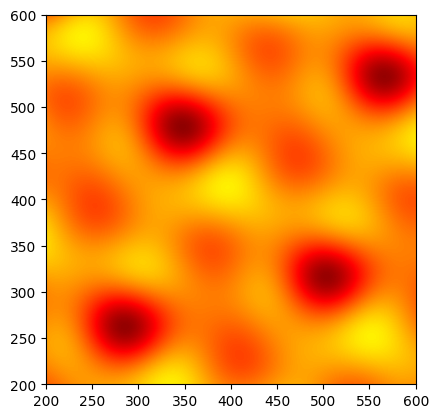

PyObject <matplotlib.image.AxesImage object at 0x7f8df9e52bb0>

In [144]:
img = ndimage.minimum_filter(np.rot90(EnergyArray), size=20)
ylim(200, 600)
xlim(200, 600)

img = ndimage.gaussian_filter(img, sigma=30)

imshow(img, cmap="hot", interpolation="gaussian")

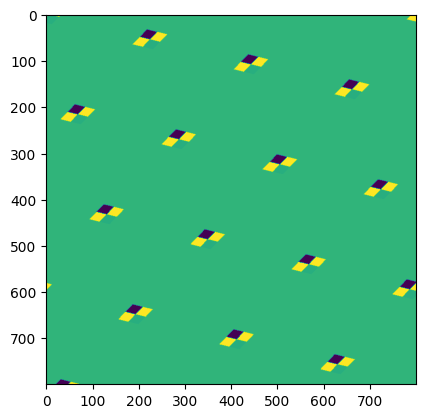

PyObject <matplotlib.image.AxesImage object at 0x7f8df9bc7190>

In [154]:
imshow(np.rot90(EnergyArrayStability))

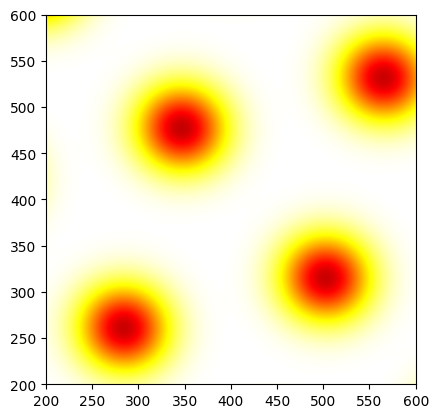

PyObject <matplotlib.image.AxesImage object at 0x7f8df9d99250>

In [148]:
img_stability = ndimage.minimum_filter(np.rot90(EnergyArrayStability), size=20)
ylim(200, 600)
xlim(200, 600)

img_stability = ndimage.gaussian_filter(img_stability, sigma=30)

imshow(img_stability, cmap="hot", interpolation="gaussian")

In [20]:
Moire_Fig = imread("Moire13.jpg");

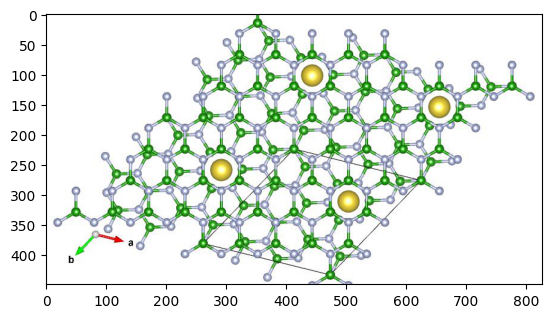

PyObject <matplotlib.image.AxesImage object at 0x7f8df81adb20>

In [280]:
imshow(Moire_Fig)
#ylim(227, 380)
#xlim(265, 622)

In [313]:
sqrt((380-227)^2+(622-265)^2)/sqrt(3)

224.24540129063965

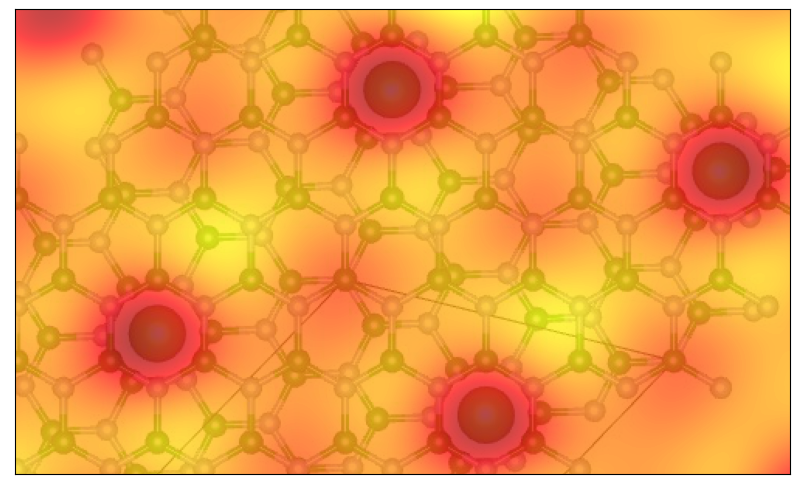

(Any[], Any[])

In [149]:
figure(figsize=(10, 10))
imshow(img, cmap="hot", interpolation="gaussian", alpha=0.9)
imshow(Moire_Fig, alpha=0.2)
xlim(200, 700)
ylim(350, 50)
xticks(Float64[])
yticks(Float64[])


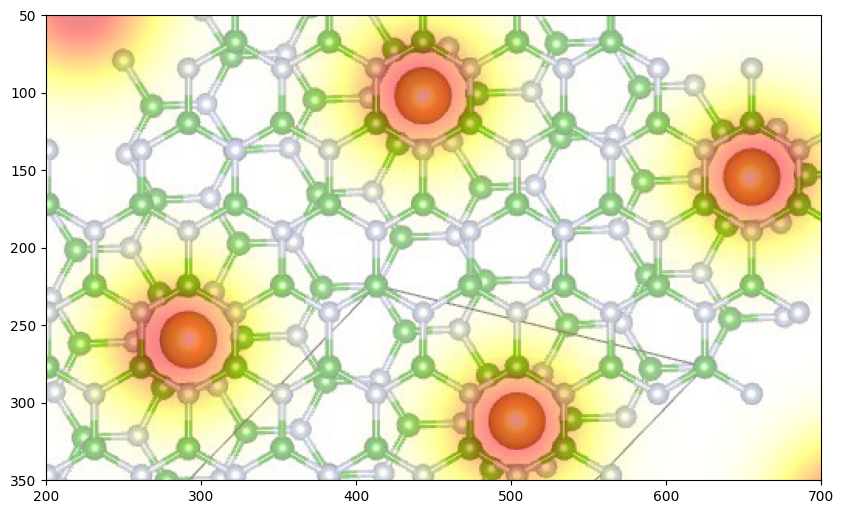

(350.0, 50.0)

In [152]:
figure(figsize=(10, 10))
imshow(img_stability, cmap="hot", interpolation="gaussian", alpha=0.9)
imshow(Moire_Fig, alpha=0.5)
xlim(200, 700)
ylim(350, 50)
#xticks(Float64[])
#yticks(Float64[])

In [23]:
pwd()

"/home/gridsan/aligho/Plasmons/Plasmons_Paper/Moire_Figs/Moire13_with_Alkali/Sodium/optimize_Na_position"

In [157]:
E = Energies+ Energies_single

10×10 Matrix{Float64}:
 -14874.5  -14874.5  -14874.5  -14874.5  …  -14875.1  -14873.2  -10242.3
 -14874.5  -14874.5  -14874.5  -14874.5     -14875.2  -14874.8  -14871.2
 -14874.5  -14874.5  -14874.5  -14874.5     -14875.1  -14875.2  -14874.8
 -14874.5  -14874.5  -14874.5  -14874.5     -14875.0  -14875.2  -14875.3
 -14874.6  -14874.6  -14874.5  -14874.6     -14875.0  -14875.1  -14875.3
 -14874.9  -14874.7  -14874.6  -14874.6  …  -14875.1  -14875.2  -14875.3
 -14875.1  -14875.1  -14874.9  -14874.8     -14875.2  -14875.2  -14875.2
 -14875.1  -14875.2  -14875.1  -14875.0     -14875.1  -14874.8  -14874.8
 -14873.2  -14874.8  -14875.2  -14875.2     -14874.8  -14873.2  -14871.2
 -10242.3  -14871.2  -14874.8  -14875.3     -14874.8  -14871.2  -10242.3

In [233]:
x = np.ndarray.flatten([collect(1:8)...])
xprime = np.ndarray.flatten([collect(3:-0.1:1)... collect(1:0.1:3)...])

y1_x = E[x, 1];
y1_y = E[1, x];
y2_x = Energies_single[x, 1];
y2_y = Energies_single[1, x];
y3_x = Energies[x, 1];
y3_y = Energies[1, x];

In [234]:
f1 = interpol.interp1d(x, y1_x)
g1 = interpol.interp1d(x, y1_y)
f2 = interpol.interp1d(x, y2_x)
g2 = interpol.interp1d(x, y2_y)
f3 = interpol.interp1d(x, y3_x)
g3 = interpol.interp1d(x, y3_y)

PyObject <scipy.interpolate.interpolate.interp1d object at 0x7f8df8ccbc20>

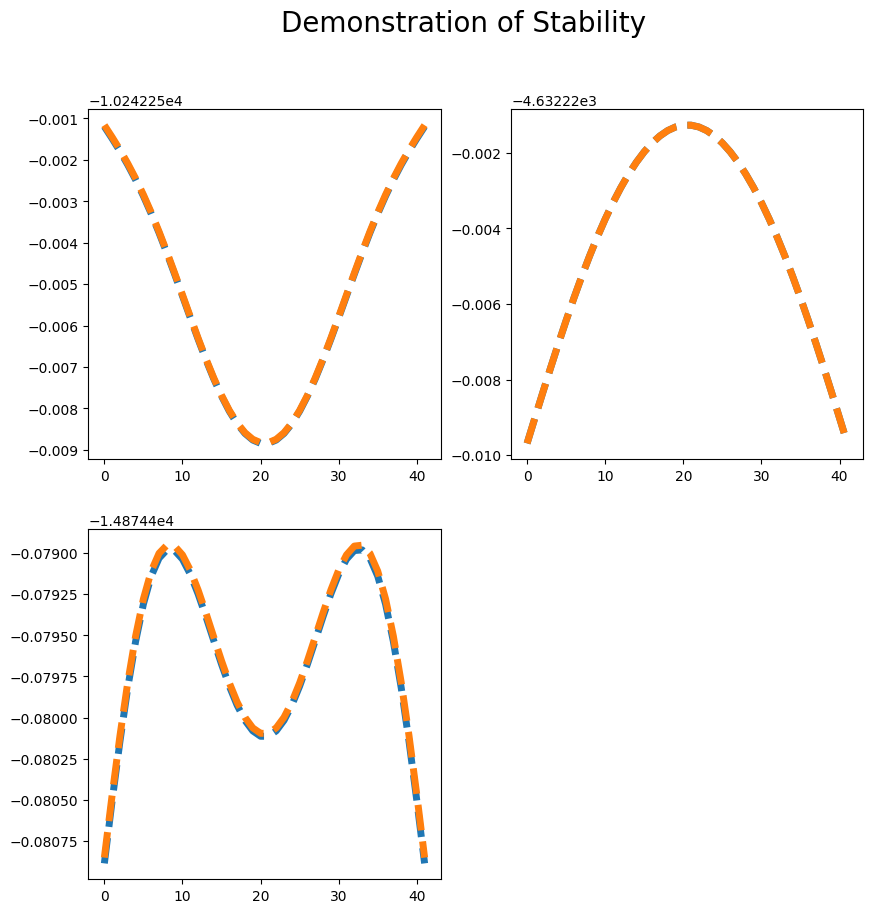

PyObject Text(0.5, 0.98, 'Demonstration of Stability')

In [239]:
figure(figsize=(10, 10))
subplot(2, 2, 1)
plot(smooth(f3(xprime)), linestyle="dashed", linewidth=5)
plot(smooth(g3(xprime)), linestyle="dashed", linewidth=5)
subplot(2, 2, 2)
plot(smooth(f2(xprime)), linestyle="dashed", linewidth=5)
plot(smooth(g2(xprime)), linestyle="dashed", linewidth=5)
subplot(2, 2, 3)
plot(smooth(f1(xprime)), linestyle="dashed", linewidth=5)
plot(smooth(g1(xprime)), linestyle="dashed", linewidth=5)
suptitle("Demonstration of Stability", fontsize=20)

In [421]:
a, b, c = ([1, 2, 3], [3, 2,1 ], [6, 6, 6])

([1, 2, 3], [3, 2, 1], [6, 6, 6])

In [432]:
unit_cell_area([v1, v2, v3])

70.45910242916717

In [431]:
(2*pi)^2/brillouin_zone_area([v1, v2, v3])

70.45910242916717